In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Wedge

(-0.1, -0.025)

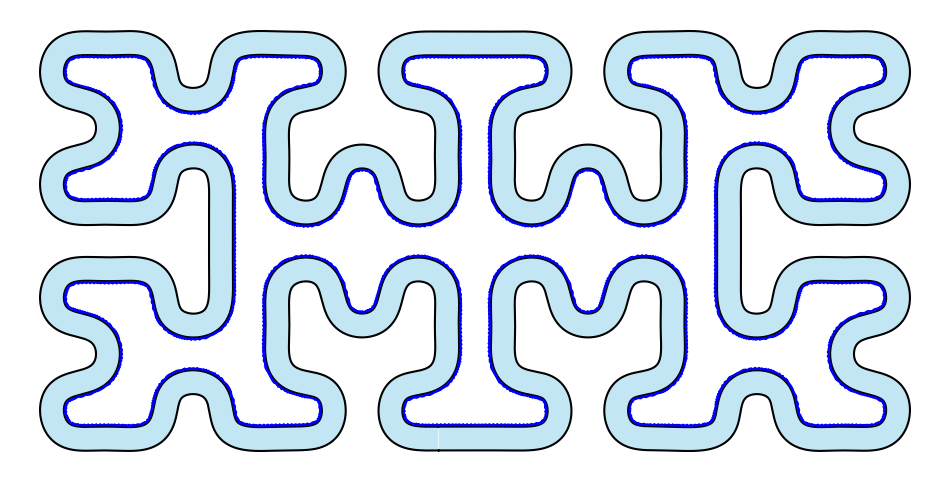

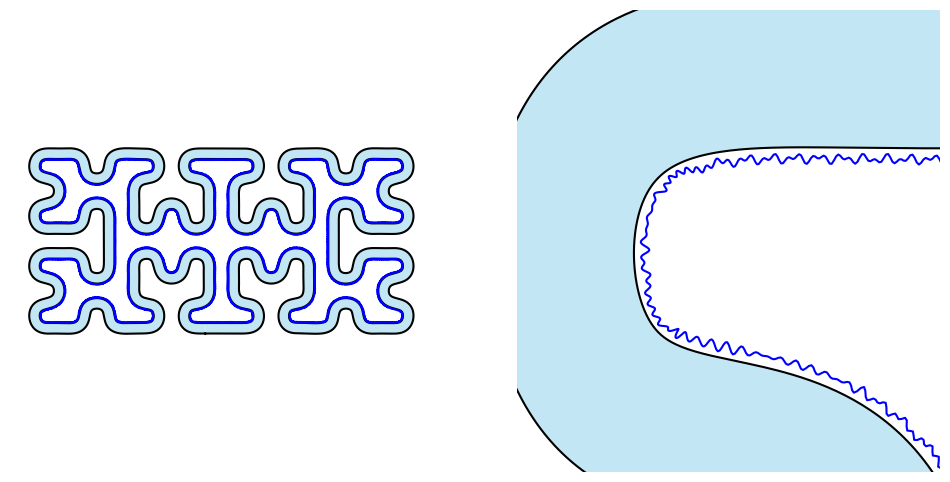

In [16]:
# numpy 1.26.4
# python 3.12.2
# scipy 1.12.0
# 

import jax
import jax.numpy as jnp
import numpy as np
from jax import random, vmap, grad, jit
from jax import lax
import matplotlib.pyplot as plt
import time
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Polygon
from matplotlib.collections import PatchCollection, PolyCollection
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import copy


def get_ctype_list(ctype):
    clist = [(ctype + i)%4 for i in [0, 0, -1, 1]]
    clist = np.roll(clist, ctype)
    return clist

def get_pytree(ctype, center_x, center_y, width, min_width):
    if (width <= min_width):
        return ((None), (ctype, center_x, center_y, width))
    else:
        ctype_list = get_ctype_list(ctype)
        center_x_list = tuple(center_x + p*width/4 for p in [1, -1, -1, 1])
        center_y_list = tuple(center_y + p*width/4 for p in [1, 1, -1, -1])
        widths = tuple(width/2 for _ in range(4))
        children = tuple(get_pytree(t, cx, cy, w, min_width) for t, cx, cy, w in zip(ctype_list, center_x_list, center_y_list, widths))
        return (children, (ctype, center_x, center_y, width))


def curve(t, t0, t1, tree, connect_type=(1, 1)):
    children = tree[0]
    ctype, cx, cy, w = tree[1]
    eventype = ctype % 2
    order = int(-1 + 2*eventype)
    
    

    connect_all = (connect_type[0], ) + tuple((i+ctype) % 2 for i in (1, 0, 1)) + (connect_type[1], )    
    
    
    if children is not None:
        t_seg = np.linspace(t0, t1, 5)
        ti = [t[np.where((t_s < t)*(t <= t_e))] for t_s, t_e in zip(t_seg[:-1], t_seg[1:])]
        children = tuple(children[(i+ctype+3) % 4] for i in range(4))
        return np.concatenate([curve(t, ts, te, child, (ct0, ct1)) for t, ts, te, ct0, ct1, child in \
                                zip(ti, t_seg[:-1], t_seg[1:], connect_all[:-1], connect_all[1:], children[::order])])
    else:
        t_norm = (t - t0)/(t1 - t0)
        cz = cx + 1j*cy
        z = w/4*np.exp(1j*(2*np.pi*order*t_norm-1*np.pi/2))
        
        if (connect_type[0] + ctype)%2 == 1: # Bend outwards
            z0 = order*w/4*np.ones_like(t_norm) - 1j *w/2 + 1j*w/2 * t_norm / 0.25
        else:
            z0 = order*w/2 + w/4*np.exp(-1j*np.pi/2 - 1j*order*t_norm*np.pi*2)
        
        if (connect_type[1] + ctype) % 2 == 1:
            z1 = -order*w/4*np.ones_like(t_norm) - 1j *w/2 + 1j*w/2 * (1.-t_norm) / 0.25
        else:
            z1 = -order*w/2 + w/4*np.exp(-1j*np.pi/2 + 1j*order*(1.-t_norm)*np.pi*2)
        
        rot = np.exp(1j*np.pi/2*ctype)
        z = np.where(t_norm < 0.25, z0, np.where(t_norm < 0.75, z, z1))
        z = cz + rot*z
        return z     
    
def double_curve(t, tree):
    z = np.concatenate([curve(t, 0, 0.5, tree), 1-curve(t-0.5, 0, .5, tree)])
    return z

def fill_between_complex_curves(z1, z2, color='skyblue', alpha=0.5, line_color='black'):
    """
    Fills the region between two complex-valued curves z1 and z2 in the complex plane.
    
    Parameters:
    - z1, z2: np.ndarray of complex numbers, same length
    - color: fill color
    - alpha: transparency
    - line_color: color of the boundary curves
    """
    assert len(z1) == len(z2), "z1 and z2 must have the same length"

    # Extract real and imaginary parts
    x1, y1 = np.real(z1), np.imag(z1)
    x2, y2 = np.real(z2), np.imag(z2)

    # Create the polygon by connecting z1 forward and z2 backward
    x = np.concatenate([x1, x2[::-1]])
    y = np.concatenate([y1, y2[::-1]])

    # Plot
    plt.fill(x, y, color=color, alpha=alpha, edgecolor='none')
    plt.plot(x1, y1, color=line_color)
    plt.plot(x2, y2, color=line_color)
    plt.axis("off")


confs = {
    "a": [0.2, 0.3, 0.8],
    "H": [0.005, 0.013, 0.03],
    "V": [1.0, 1.0, 1.0],
}

c_idx = 1
a = confs["a"][c_idx] # Detail size
H = confs["H"][c_idx] # Height of the roof
V = confs["V"][c_idx]  # Roof velocity



N = 200
tree = get_pytree(0, 0.5, 0.5, 1, a)
t = np.linspace(0, 1., N+1)[1:]

t_eval = np.linspace(0, 1., 10000+1)[1:]
t_fine_eval = np.linspace(0, 1., 20000+1)[1:]

z = 1j * double_curve(t, tree)
z = z - np.mean(z)  # Center the curve at the origin
zmax = np.max(np.abs(z))
z = z / zmax * 0.5  # Normalize to fit in unit circle

zfft = jnp.fft.fft(z)
freq = jnp.fft.fftfreq(N, 1/N)
zfunc = lambda t: jnp.sum(zfft * jnp.exp(1j * 2 * np.pi * freq * t)) / N

def curvature_func(zfunc):
    def curvature(t):
        d2z = grad(grad(zfunc, holomorphic=True), holomorphic=True)(t + 0j)
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.abs(dz)
        det = dz.real * d2z.imag - dz.imag * d2z.real
        #curvature_value = jnp.abs(d2z) / (norm**3 + 1e-10)  # Avoid division by zero
        curvature_value = jnp.abs(det) / (norm**3 + 1e-3)  # Avoid division by zero
        return curvature_value
    return curvature


def normal_func(zfunc):
    def normal(t):
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.sqrt(dz.real**2 + dz.imag**2)
        return dz / (1j * norm)
    return normal

def tangent_func(zfunc):
    def tangent(t):
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.sqrt(dz.real**2 + dz.imag**2)
        return dz / norm
    return tangent

normal = normal_func(zfunc)
outside_fcn = lambda t: zfunc(t) - H * normal(t)
inside_fcn = lambda t: zfunc(t) + H * normal(t)
inside_crv = curvature_func(inside_fcn)
inside_normal = normal_func(inside_fcn)
outside_tangent = tangent_func(outside_fcn)


eps = 0.07 * H
eps_freq = int(2.0 / eps)
prod = lambda z: jnp.sin(z.real*eps_freq) * jnp.sin(z.imag*eps_freq)
roughness = lambda t: eps * (2.0 + prod((1+0.3j)*inside_fcn(t)))  # Roughness function, can be modified
rough_fcn = lambda t: inside_fcn(t) + roughness(t)*inside_normal(t)


vel_fcn = lambda t: V * outside_tangent(t)


zt = vmap(zfunc)(t_eval)
nt = vmap(normal)(t_eval)

zft = vmap(outside_fcn)(t_eval)
zrt = vmap(inside_fcn)(t_eval)

rft = vmap(rough_fcn)(t_fine_eval)


#plt.plot(t_eval, vmap(amplitude)(t_eval), label='Curvature', color='orange')
# Plot the curves to illustrate the domain
plt.figure(figsize=(12, 6))
fill_between_complex_curves(zft, zrt, color='skyblue', alpha=0.5, line_color='black')
plt.plot(rft.real, rft.imag, color='blue', label='Rough Roof')
plt.axis("equal")


plt.figure(figsize=(12, 6))

plt.subplot(121)
fill_between_complex_curves(zft, zrt, color='skyblue', alpha=0.5, line_color='black')
plt.plot(rft.real, rft.imag, color='blue', label='Rough Roof')
plt.axis("equal")

plt.subplot(122)
fill_between_complex_curves(zft, zrt, color='skyblue', alpha=0.5, line_color='black')
plt.plot(rft.real, rft.imag, color='blue', label='Rough Roof')

#plt.xlim(0.3, 0.4)
#plt.ylim(0.1, 0.2)
#plt.axis("equal")

plt.ylim([0.15, 0.225])
plt.xlim([-0.1, -0.025])


In [17]:
import pygmsh as pg
import dolfin as dl
import numpy as np
import matplotlib.pyplot as plt
from hmm.stokes_fenics import StokesMacProb, StokesData, MacroSol, MacroSolver, StokesMicProb, MicroSolver, StokesHMMProblem, macro_to_micro, micros_to_macro
from hmm.hmm import IterativeHMMSolver
from util.basis_scaled import FourBasis, ScaleShiftedBasis
from util.mesh_tools import Box, order_connected_vertices, boundary_bbox_tree, find_intersection_on_segment, plot_boundary_mesh
from util.random import smooth_random_loop_fourier_coef, fourierGP_2D_lerp
from util.logger import EventTracker
from util.plot_tools import remove_axes
from dataclasses import dataclass
import meshio
import gmsh
from hmm.stokes_deep_fenics import DeepMicroSolverFenics, get_net
from typing import List, Tuple, Callable, Dict, Optional, Union

np.random.seed(0)
MESH_PATH = "/home/emastr/deep-micro-slip-model/data/mesh/"
figures_dir = "/home/emastr/deep-micro-slip-model/data/figures/"
simulation_dir = "/home/emastr/deep-micro-slip-model/data/stokes_fenics/"

def curvature_func(zfunc):
    def curvature(t):
        d2z = grad(grad(zfunc, holomorphic=True), holomorphic=True)(t + 0j)
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.abs(dz)
        det = dz.real * d2z.imag - dz.imag * d2z.real
        #curvature_value = jnp.abs(d2z) / (norm**3 + 1e-10)  # Avoid division by zero
        curvature_value = jnp.abs(det) / (norm**3 + 1e-3)  # Avoid division by zero
        return curvature_value
    return curvature

def normal_func(zfunc):
    def normal(t):
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.sqrt(dz.real**2 + dz.imag**2)
        return dz / (1j * norm)
    return normal

def tangent_func(zfunc):
    def tangent(t):
        dz = grad(zfunc, holomorphic=True)(t + 0j)
        norm = jnp.sqrt(dz.real**2 + dz.imag**2)
        return dz / norm
    return tangent

def list_sum(lists):
    return [item for sublist in lists for item in sublist]

def create_mesh(mesh, cell_type, prune_z=False):
    cells = mesh.get_cells_type(cell_type)
    cell_data = mesh.get_cell_data("gmsh:physical", cell_type)
    points = mesh.points[:,:2] if prune_z else mesh.points
    out_mesh = meshio.Mesh(points=points, cells={cell_type: cells}, cell_data={"name_to_read":[cell_data]})
    return out_mesh


def point_to_segment_distance(p, a, b):
    """
    Compute the distance from point p to line segment ab.
    
    Parameters:
        p: np.array of shape (2,)
        a: np.array of shape (2,)
        b: np.array of shape (2,)
    
    Returns:
        Distance (float)
    """
    ab = b - a
    ap = p - a
    t = np.dot(ap, ab) / np.dot(ab, ab)
    t = np.clip(t, 0.0, 1.0)  # clamp to segment
    closest = a + t * ab
    return np.linalg.norm(p - closest)

def distance_to_curve(point, curve_points):
    """
    Compute the minimum distance from a point to a piecewise linear curve.

    Parameters:
        point: np.array of shape (2,)
        curve_points: np.array of shape (N, 2)

    Returns:
        Minimum distance (float)
    """
    N = len(curve_points)
    min_dist = float("inf")
    for i in range(N):
        a = curve_points[i]
        b = curve_points[(i + 1)%N]
        dist = point_to_segment_distance(point, a, b)
        min_dist = min(min_dist, dist)
    return min_dist


class PWLCurve(dl.SubDomain):
    def __init__(self, x, tol, is_boundary):
        super().__init__()
        self.is_boundary = is_boundary
        self.tol = tol
        self.vertices = x

    def inside(self, x, on_boundary):
        return bool(distance_to_curve(x, self.vertices)<=self.tol) and (on_boundary or not self.is_boundary)


@dataclass
class RoughTube:
    # Main parameters
    H: float
    a: float
    eps: float

    # Discrete points
    inner_points: np.ndarray = None
    outer_points: np.ndarray = None
    roughness_points: np.ndarray = None
    
    # Functions
    inside_fcn: Callable = None
    outside_fcn: Callable = None
    rough_fcn: Callable = None
    
    # File names
    name: str = ""
    rough_name: str = ""
    
    @staticmethod
    def from_main_pars(H, a, eps, name):
        N = 200
        Neval = 1000
        Nrough = 20000
        
        eps_freq = 2.0/eps #int(0.8 / eps)
        tree = get_pytree(0, 0.5, 0.5, 1, a)
        
        t = np.linspace(0, 1., N+1)[1:]
        z = 1j * double_curve(t, tree)
        z = z - jnp.mean(z)
        zmax = np.max(np.abs(z))
        z = z / zmax * 0.5  # Normalize to fit in unit circle
        zfft = jnp.fft.fft(z)
        freq = jnp.fft.fftfreq(N, 1/N)
        zfunc = lambda t: jnp.sum(zfft * jnp.exp(1j * 2 * np.pi * freq * t)) / N
            
        normal = normal_func(zfunc)
        outside_fcn = lambda t: zfunc(t) - H * normal(t)
        inside_fcn = lambda t: zfunc(t) + H * normal(t)
        inside_normal = normal_func(inside_fcn)

        prod = lambda z: jnp.sin(z.real*eps_freq) * jnp.sin(z.imag*eps_freq)
        roughness = lambda t: eps * (2.0 + prod((1+0.3j)*inside_fcn(t))) 
        rough_fcn = lambda t: inside_fcn(t) + roughness(t)*inside_normal(t)
        
        t_eval = np.linspace(0, 1., Neval+1)[1:]
        zft = vmap(outside_fcn)(t_eval)
        zrt = vmap(inside_fcn)(t_eval)
        
        t_fine_eval = np.linspace(0, 1., Nrough+1)[1:]
        rft = vmap(rough_fcn)(t_fine_eval)
        
        x_outside = np.array([zft.real, zft.imag]).T
        x_inside = np.array([zrt.real, zrt.imag]).T
        x_rough = np.array([rft.real, rft.imag]).T        
        return RoughTube(H, a, eps, x_inside, x_outside, x_rough, inside_fcn, outside_fcn, rough_fcn, name=name, rough_name=name)
    
    
    def get_micro_points(self, N=100):
        t = np.linspace(0, 1., N+1)[1:]
        zft = vmap(self.inside_fcn)(t)
        return np.array([zft.real, zft.imag]).T
    
    
    def create_domains(self, TOL):
        #outer = PWLCurve(self.outer_points, TOL, False)
        #inner = PWLCurve(self.inner_points, TOL, False)
        outer_bdry = PWLCurve(self.outer_points, TOL, True)
        inner_bdry = PWLCurve(self.inner_points, TOL, True)
        inner_nobdry = PWLCurve(self.inner_points, TOL, False)
        return outer_bdry, inner_bdry, inner_nobdry
    
    
    @staticmethod
    def curve_loop(geom, points, lcar):
        N = points.shape[0]
        geom_points = []
        for x in points:
            if lcar is None:
                geom_points.append(geom.add_point([x[0], x[1]]))
            else:
                geom_points.append(geom.add_point([x[0], x[1]], lcar))
        curve = geom.add_bspline(geom_points + [geom_points[0]])
        l  = geom.add_curve_loop([curve])
        return l
    
    
    def save_geometry(self, file_name, scale=None):
        if scale is None:
            scale = self.H*0.5
        
        # Create the geometry
        with pg.geo.Geometry() as geom:
            outer = self.curve_loop(geom, self.outer_points, lcar=scale)
            inner = self.curve_loop(geom, self.inner_points, lcar=scale)
            
            surf = geom.add_plane_surface(outer, holes=[inner])
            geom.add_physical(surf, label='Inside')
            geom.add_physical(outer.curves, label='Dirichlet')
            geom.add_physical(inner.curves, label='Roughness')
                        
            mesh = geom.generate_mesh(dim=2)
            gmsh.write(f'{MESH_PATH}tube_temp.msh')        
        
        mesh = meshio.read(f'{MESH_PATH}tube_temp.msh')
        
        bdry = create_mesh(mesh, "line", True)
        mesh = create_mesh(mesh, "triangle", True)
        
        meshio.write(f'{MESH_PATH}{file_name}_tube_volume.xdmf', mesh)
        meshio.write(f'{MESH_PATH}{file_name}_tube_boundary.xdmf', bdry)
        self.name = file_name
        
    
    def create_roughness(self, file_name, scale=None):
        if scale is None:
            scale = self.eps
        with pg.geo.Geometry() as geom:
            l  = self.curve_loop(geom, self.roughness_points, scale)
            geom.add_physical(l.curves, label='Roughness')
            mesh = geom.generate_mesh(dim=1)
            gmsh.write(f'{MESH_PATH}tube_temp.msh')        
        
        mesh = meshio.read(f'{MESH_PATH}tube_temp.msh')
        mesh = create_mesh(mesh, "line", True)
        meshio.write(f'{MESH_PATH}{file_name}_tube_roughness.xdmf', mesh)
        self.rough_name = file_name
    
    
    def load_meshes(self):
        file = dl.XDMFFile(f'{MESH_PATH}{self.name}_tube_volume.xdmf')
        mesh = dl.Mesh()
        file.read(mesh)

        bdry_file = dl.XDMFFile(f'{MESH_PATH}{self.name}_tube_boundary.xdmf')
        bdry = dl.Mesh()
        bdry_file.read(bdry)

        rough_file = dl.XDMFFile(f'{MESH_PATH}{self.rough_name}_tube_roughness.xdmf')
        bdry_rough = dl.Mesh()
        rough_file.read(bdry_rough)
        return mesh, bdry, bdry_rough
    
    



        

(-0.1, -0.025)

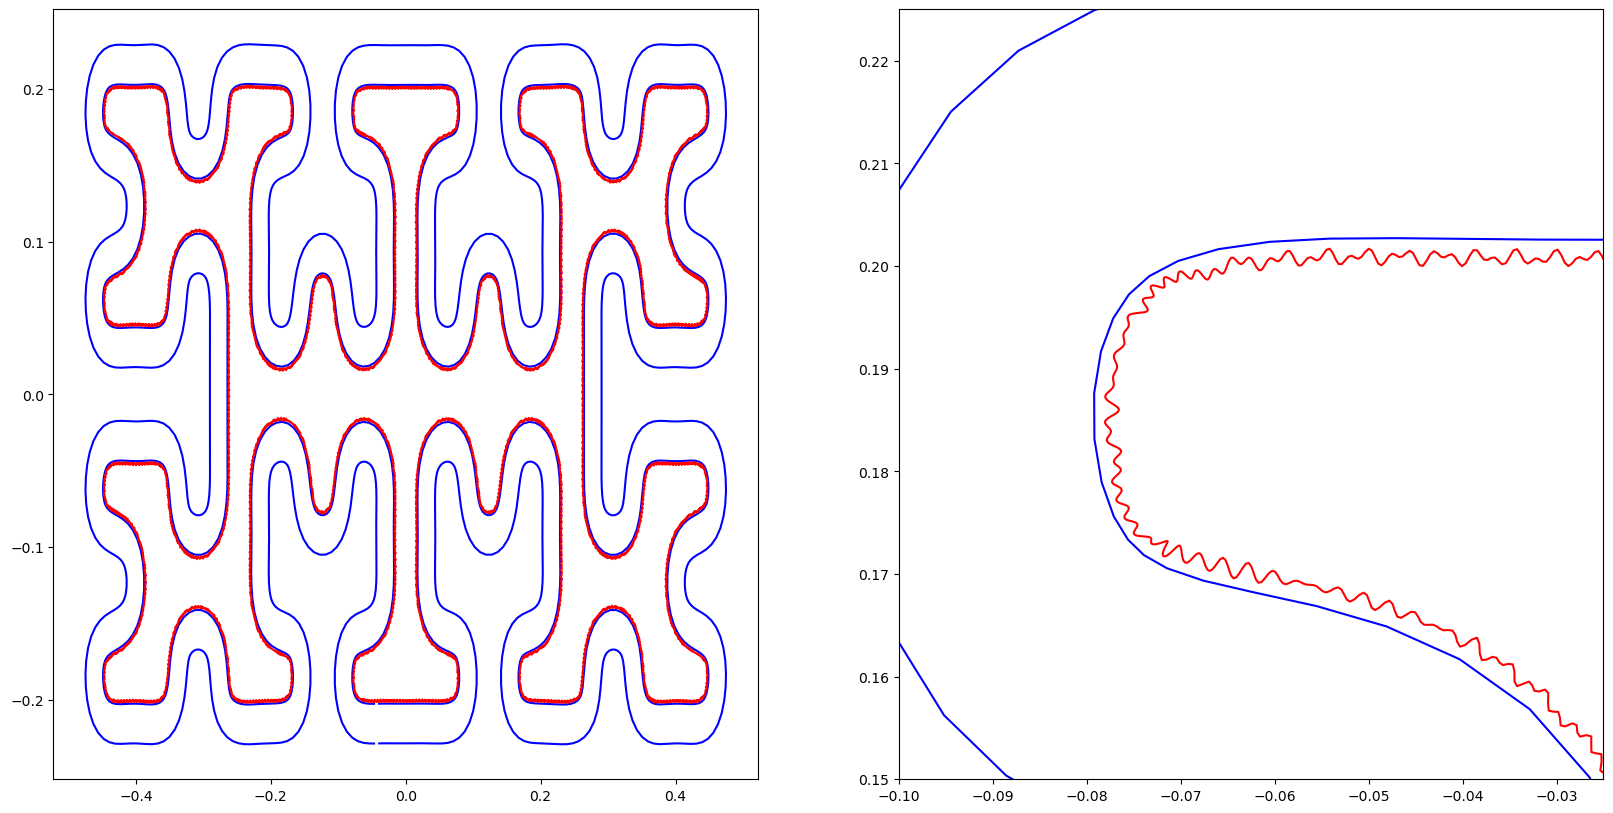

In [18]:
confs = {
    "a": [0.2, 0.3, 0.8],
    "H": [0.005, 0.013, 0.03],
    "V": [1.0, 1.0, 1.0],
}

c_idx = 1
a = confs["a"][c_idx] # Detail size
H = confs["H"][c_idx] # Height of the roof
V = confs["V"][c_idx]  # Roof velocity
#eps = 0.05 * H
eps = 0.07 * H

data = RoughTube.from_main_pars(H, a, eps, name='test_mesh')
TOL = 0.001


plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.plot(data.outer_points[:, 0], data.outer_points[:, 1], color='blue')
plt.plot(data.inner_points[:, 0], data.inner_points[:, 1], color='blue')
plt.plot(data.roughness_points[:, 0], data.roughness_points[:, 1], color='red')



plt.subplot(122)
plt.plot(data.outer_points[:, 0], data.outer_points[:, 1], color='blue')
plt.plot(data.inner_points[:, 0], data.inner_points[:, 1], color='blue')
plt.plot(data.roughness_points[:, 0], data.roughness_points[:, 1], color='red')

plt.ylim([0.15, 0.225])
plt.xlim([-0.1, -0.025])

(-0.1, -0.025)

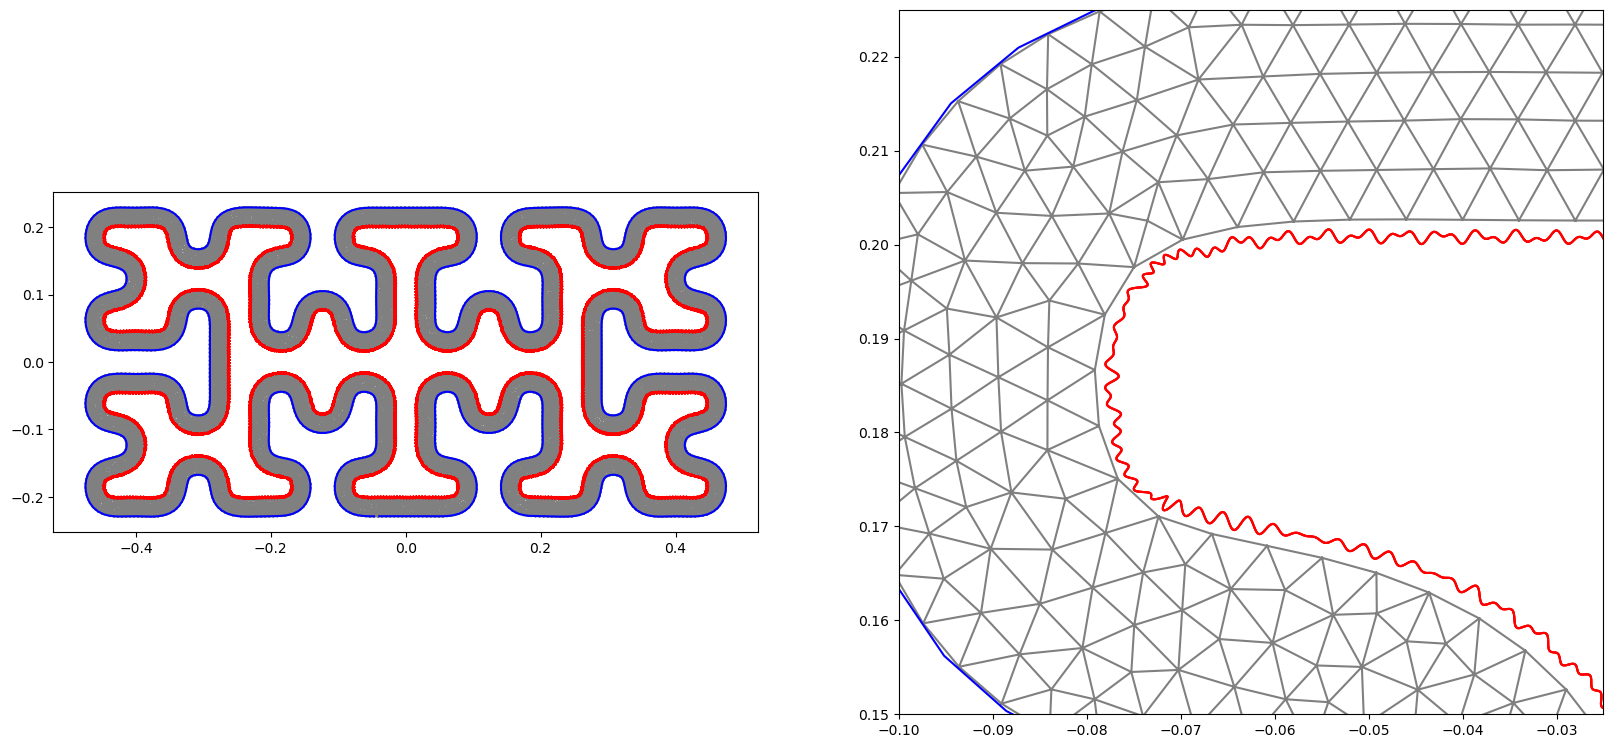

In [19]:


#### ROUGHNESS FUNCTION ####
data.create_roughness('test_mesh_2', eps*0.1)
data.save_geometry('test_mesh', 0.006)
mesh, mesh_smooth_bdry, mesh_bdry_rough = data.load_meshes()
dom_outer_bdry, dom_inner_bdry, dom_inner_nobdry = data.create_domains(TOL=TOL)


plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.plot(data.outer_points[:, 0], data.outer_points[:, 1], color='blue')
dl.plot(mesh)
plot_boundary_mesh(mesh_bdry_rough, color='r')


plt.subplot(122)
plt.plot(data.outer_points[:, 0], data.outer_points[:, 1], color='blue')
dl.plot(mesh)
plot_boundary_mesh(mesh_bdry_rough, color='r')

plt.ylim([0.15, 0.225])
plt.xlim([-0.1, -0.025])

### Problem Formulation

In [20]:
import matplotlib.tri as tri

# Define the function spaces
P2 = dl.VectorElement(family='P', cell=dl.triangle, degree=2)
P1 = dl.FiniteElement(family='P', cell=dl.triangle, degree=1)
P2P1 = P2 * P1
W = dl.FunctionSpace(mesh, P2P1)
U, P = W.split() 
Ux, Uy = U.split()

# Boundary Conditions
bcu_outer = dl.DirichletBC(U, dl.Expression((f'1', f'0'), degree=2), dom_outer_bdry)
bcu_inner = dl.DirichletBC(U, dl.Constant((0., 0.)), dom_inner_bdry)


stokes_data = StokesData.from_mesh(mesh, dom_inner_nobdry, data.roughness_points, W, [bcu_outer])


### HMM SETUP

In [21]:
alpha_means = []
    
class GaussianRBFInterp:
    def __init__(self, x, a, scale=1.0):
        self.a = a
        self.scale = scale
        self.basis = lambda y: np.array([self.rbf(x_, y) for x_ in x])
        
        
    def __call__(self, x, y):
        xy = np.array([x, y])
        basis = self.basis(xy)
        return np.dot(basis, self.a) / np.sum(basis)
    
    
    def rbf(self, x, y):
        return np.exp(-np.linalg.norm(x - y)**2 / self.scale**2)


def interp(x, a):
    return GaussianRBFInterp(x, [-a_ for a_ in a], scale=2e-1)

Nmic = 256
mac = StokesMacProb(stokes_data, interp=interp, alpha0=lambda x,y: 0.01, lam=1e3)
mac_solver = MacroSolver()
projection_op = lambda *args: macro_to_micro(*args, N=7)
pts = data.get_micro_points(Nmic)

Notation dx[meshfunction] is deprecated. Please use dx(subdomain_data=meshfunction) instead.


Building point search tree to accelerate distance queries.
Computed bounding box tree with 2149 nodes for 1075 points.


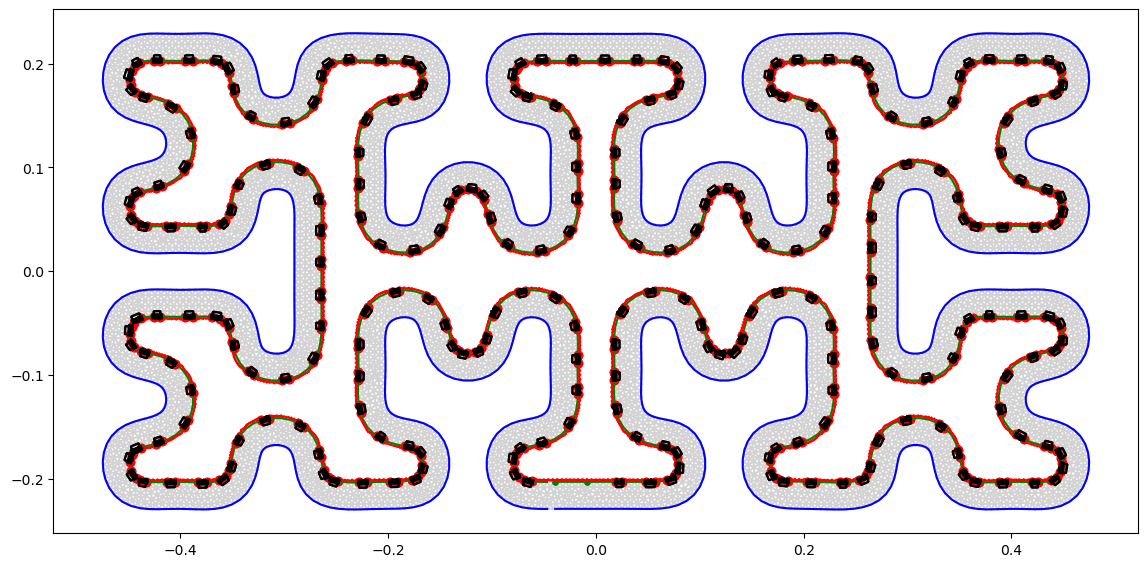

In [22]:


plt.figure(figsize=(14, 7))
dl.plot(mesh, color='lightgray')
plt.plot(data.outer_points[:, 0], data.outer_points[:, 1], color='blue', label='Outer boundary')
plt.plot(data.inner_points[:, 0], data.inner_points[:, 1], color='green', label='Inner boundary')
plt.plot(data.roughness_points[:, 0], data.roughness_points[:, 1], color='red', label='Roughness points')
plt.scatter(pts[:, 0], pts[:, 1], c='green', s=15, label='Micro points')
#plt.xlim([-0.04, -0.01])
#plt.ylim([-0.18, -0.15])

#plt.xlim([-0.75,0.75])
#plt.ylim([-0.25,0.25])

#plt.xlim([-0.35,-0.25])
#plt.ylim([0,0.1])


micros = []
for pt in pts[:-2]:
    mic = StokesMicProb(stokes_data, pt, projection_op=projection_op, debug=False, width=6*eps, height=5*eps, corner_w=eps, pad=12*eps, n_refine=1)
    #mic = StokesMicProb(stokes_data, pt, projection_op=projection_op, debug=True, width=7*eps, height=5*eps, corner_w=eps, pad=14*eps, n_refine=0)
    micros.append(mic)
    mic.plot(plt.gca(), color='black')
hmm_prob = StokesHMMProblem(mac, micros, data)


for mic in micros:
    mic.plot(plt.gca(), color='black')



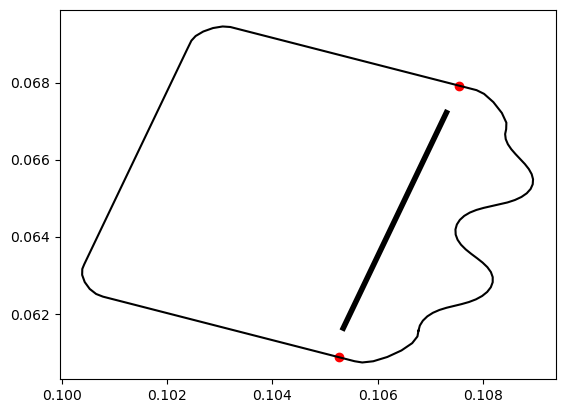

In [23]:
plt.figure()
micros[140].plot(plt.gca(), color='black')

In [24]:
import torch
from architecture.session import egeofno_ver1, svdfno_ver2, fno_ver3, svdfno_ver3
net_dir = "/mnt/data0/emastr/training/article_training_lowline/"
device = "cpu" # "cuda:0"
num_pts = 256
#net, net_settings = get_net(f"{net_dir}fnoskip_big_data_{40000}.Torch", 256, "cpu", "float")
net_type = 0# 0: egeofno, 1: svdfno, 2: fno_vanilla
# net_type 0 works well

if net_type == 0:
    net = egeofno_ver1(device=device)
    net_data = torch.load(f"{net_dir}fno_ver1_seed0_40000.Torch", map_location=torch.device(device))
elif net_type == 1:
    net = svdfno_ver2(device=device)
    net_data = torch.load(f"{net_dir}svdfno_ver2_seed0_40000.Torch", map_location=torch.device(device))
else:
    net = fno_ver3(device=device)
    net_data = torch.load(f"{net_dir}fno_vanilla_ver3_seed0_40000.Torch", map_location=torch.device(device))

net.load_state_dict(net_data["state dict"])
net_settings =  {"num_pts": num_pts, \
                 "input_features": net_data["settings"]["input_features"], \
                 "output_features": net_data["settings"]["output_features"],\
                 "device": device, "dtype": torch.float}
#print(net_settings["input_features"])
print(net_data["settings"]["output_features"])


if False:
    #net, net_settings = get_net(f"{net_dir}fnoskip_big_data_{40000}.Torch", 256, "cpu", "float")
    num_pts = 256
    #net = egeofno_ver2(device=device)
    net = svdfno_ver3(device=device)
    net_data = torch.load(f"{net_dir}svdfno_ver3_seed0_40000.Torch", map_location=torch.device(device))
    #net_data = torch.load(f"{net_dir}fno_ver2_seed0_40000.Torch", map_location=torch.device(device))
    net.load_state_dict(net_data["state dict"])
    #print(list(net_data["settings"].keys()))
    net_settings =  {"num_pts": num_pts, "input_features": net_data["settings"]["input_features"], "device": device, "dtype": torch.float}


['rt', 'rn', 'drt_norm', 'drn_norm']


In [25]:
logger = EventTracker()

alpha_res = []
alphas = []

def cb_save(iter, macro_sols, micro_sols):
    tmp = np.array([mic.alpha for mic in micro_sols])
    if len(alphas) != 0:
        delta = alphas[-1] - tmp
        alpha_res.append(np.linalg.norm(delta) / abs(np.mean(tmp)))
    alphas.append(tmp)
    
    tmp2 = alpha_res[-1] if len(alpha_res) != 0 else 0
    print(f"Mean alpha: {np.mean(tmp)}, res: {tmp2}",)
    
logger.start_event("Precompute Micros")
#mic_solvers = [MicroSolver(mic , tol=1e-6) for mic in micros]
mic_solvers = [DeepMicroSolverFenics(m, net, net_settings) for m in micros]
print([ms.can_solve(m) for ms, m in zip(mic_solvers, micros)])

logger.end_event("Precompute Micros")

hmm_solver = IterativeHMMSolver(mac_solver, mic_solvers)
guess = mac_solver.solve(mac, verbose=True)
macro_sol, micro_sols = hmm_solver.solve(hmm_prob, macro_guess=guess, maxiter=6, verbose=True, logger =logger, tol=1e-5, callback=cb_save)


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, Tru

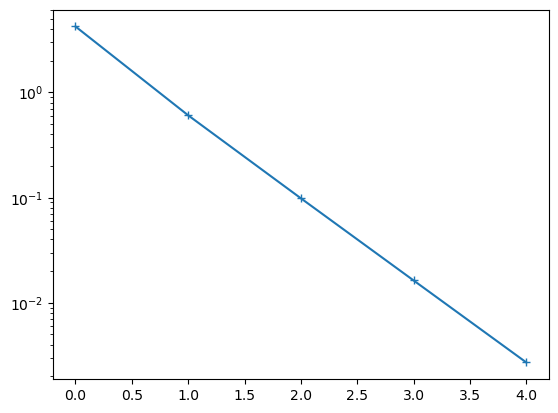

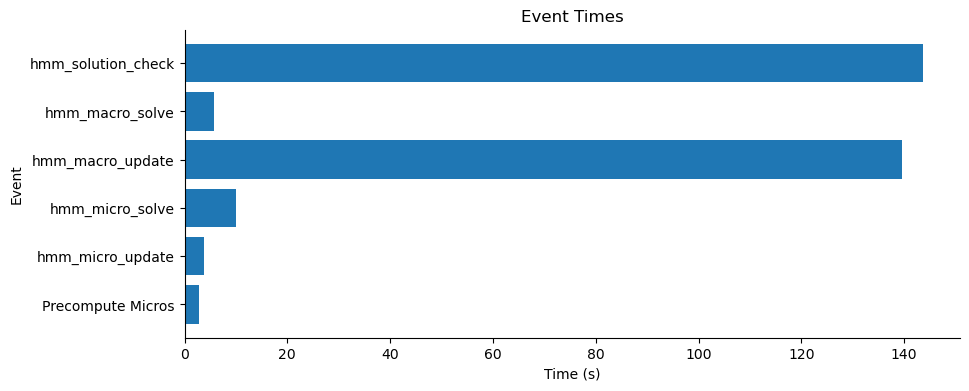

In [26]:

plt.semilogy(alpha_res, '+-')

plt.figure(figsize=(10,4))
logger.barplot_logs(plt.gca())

np.savez(f'{simulation_dir}/hmm_classic_conv.npz', alpha_res=alpha_res)

Object cannot be plotted directly, projecting to piecewise linears.
Object cannot be plotted directly, projecting to piecewise linears.
Object cannot be plotted directly, projecting to piecewise linears.


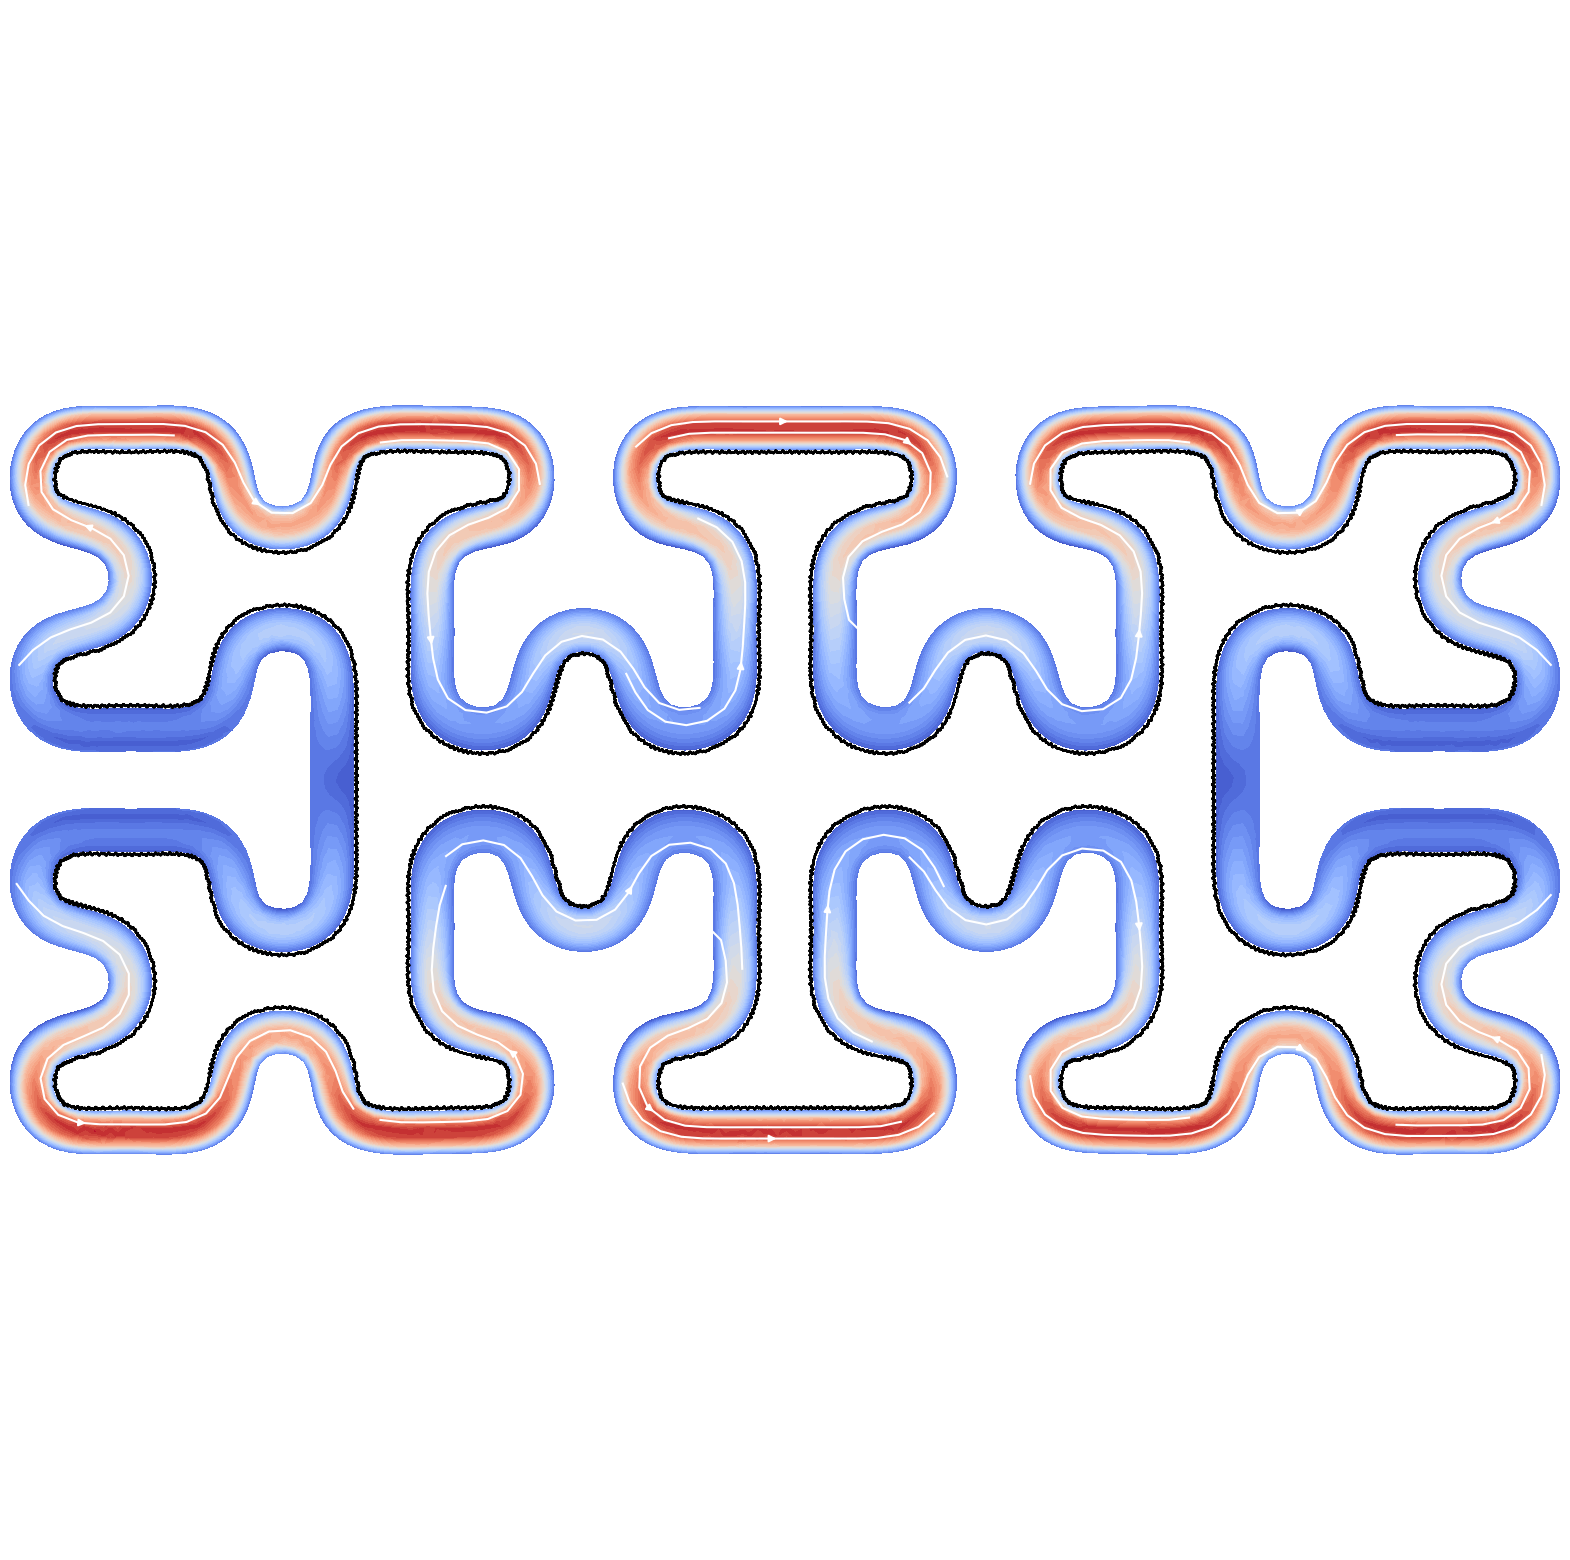

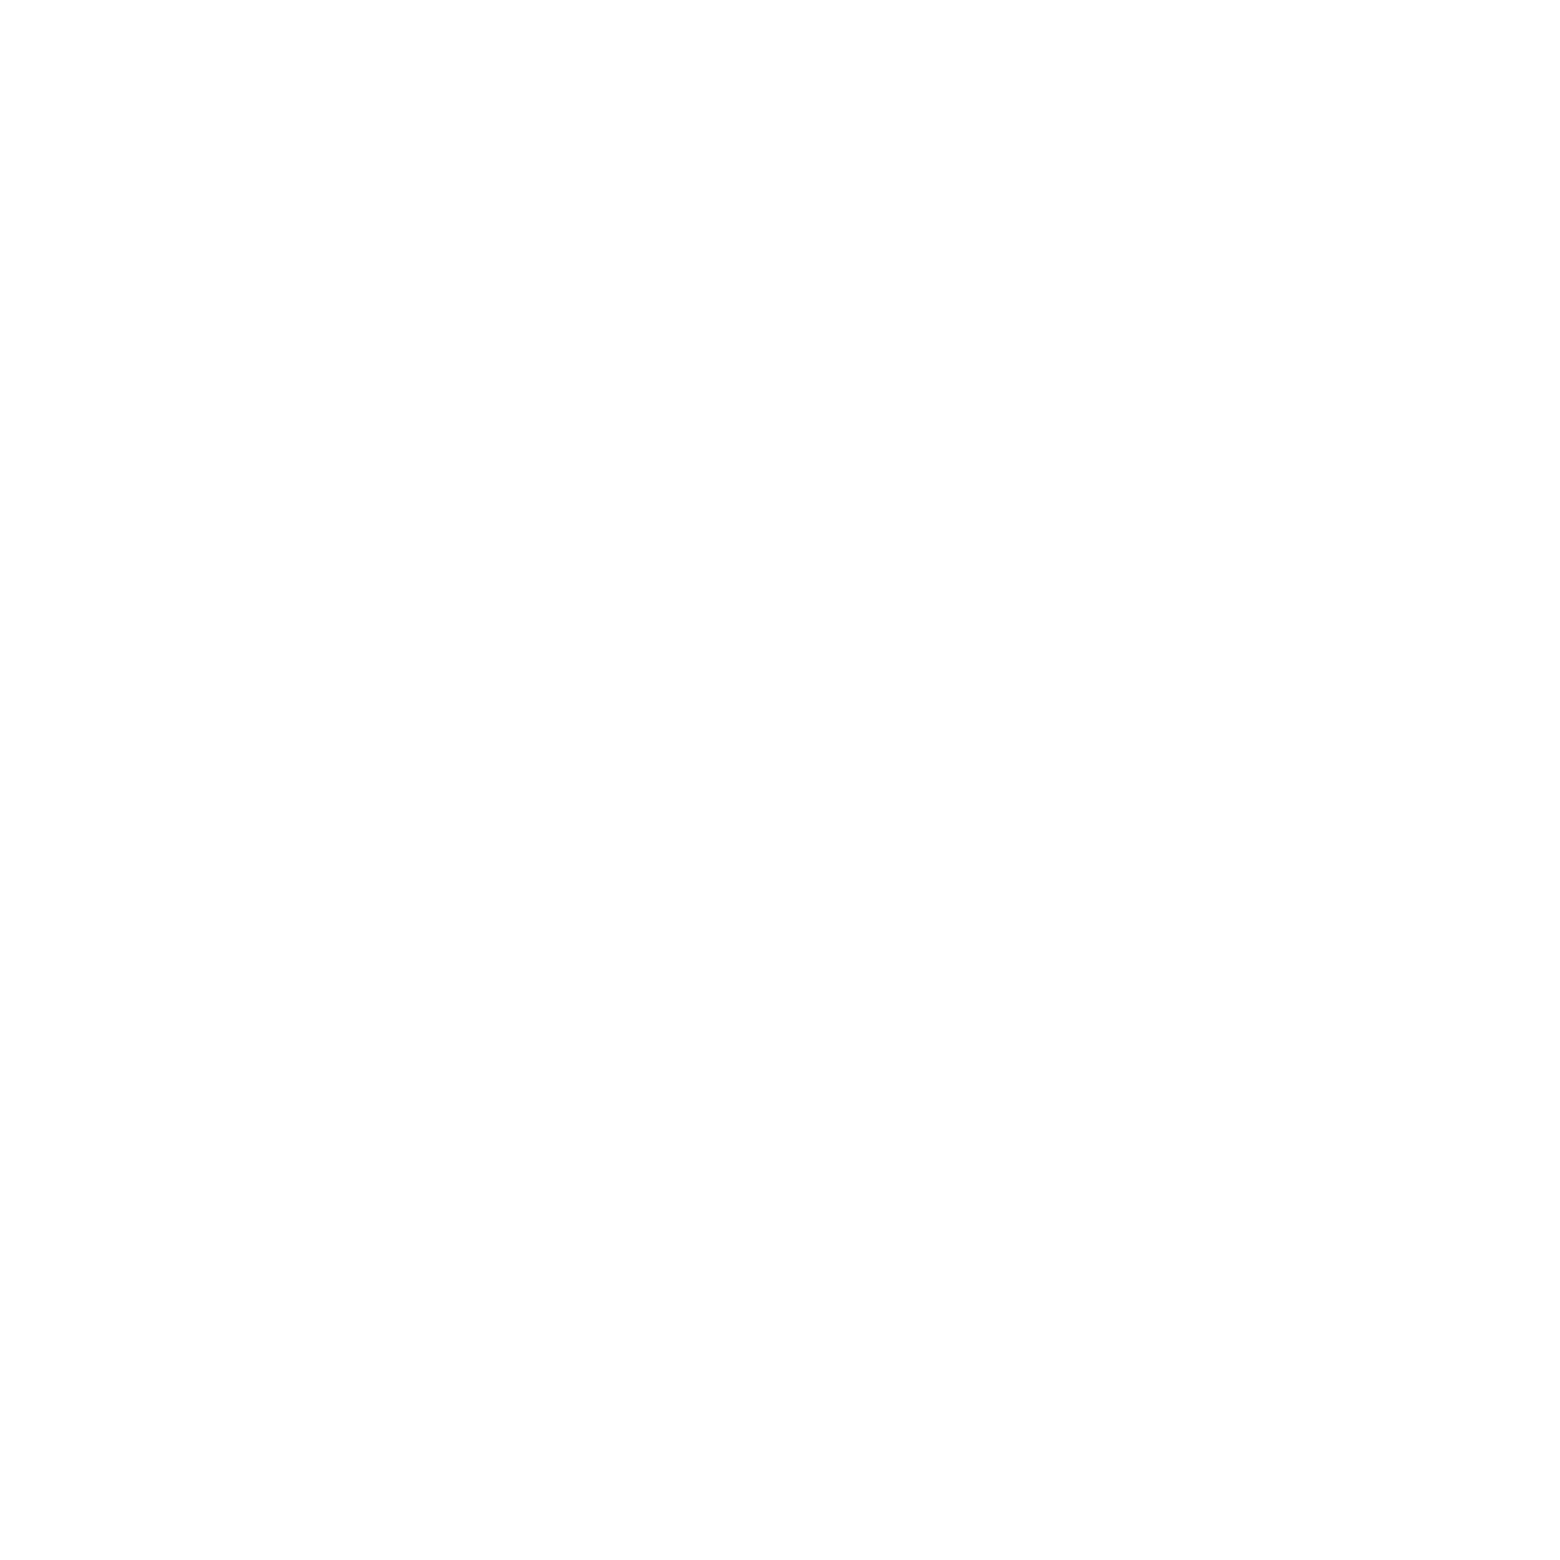

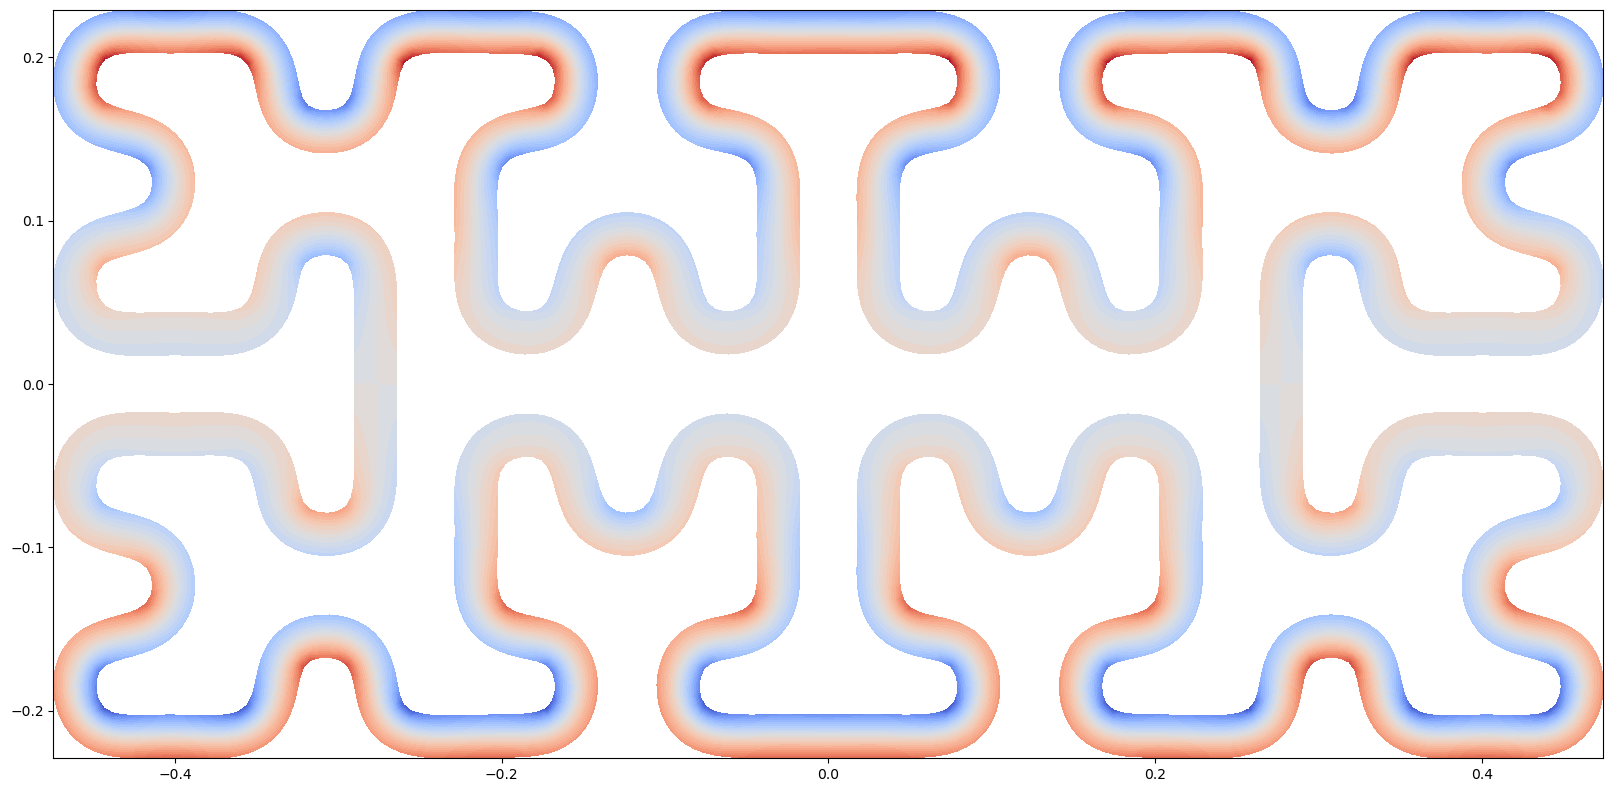

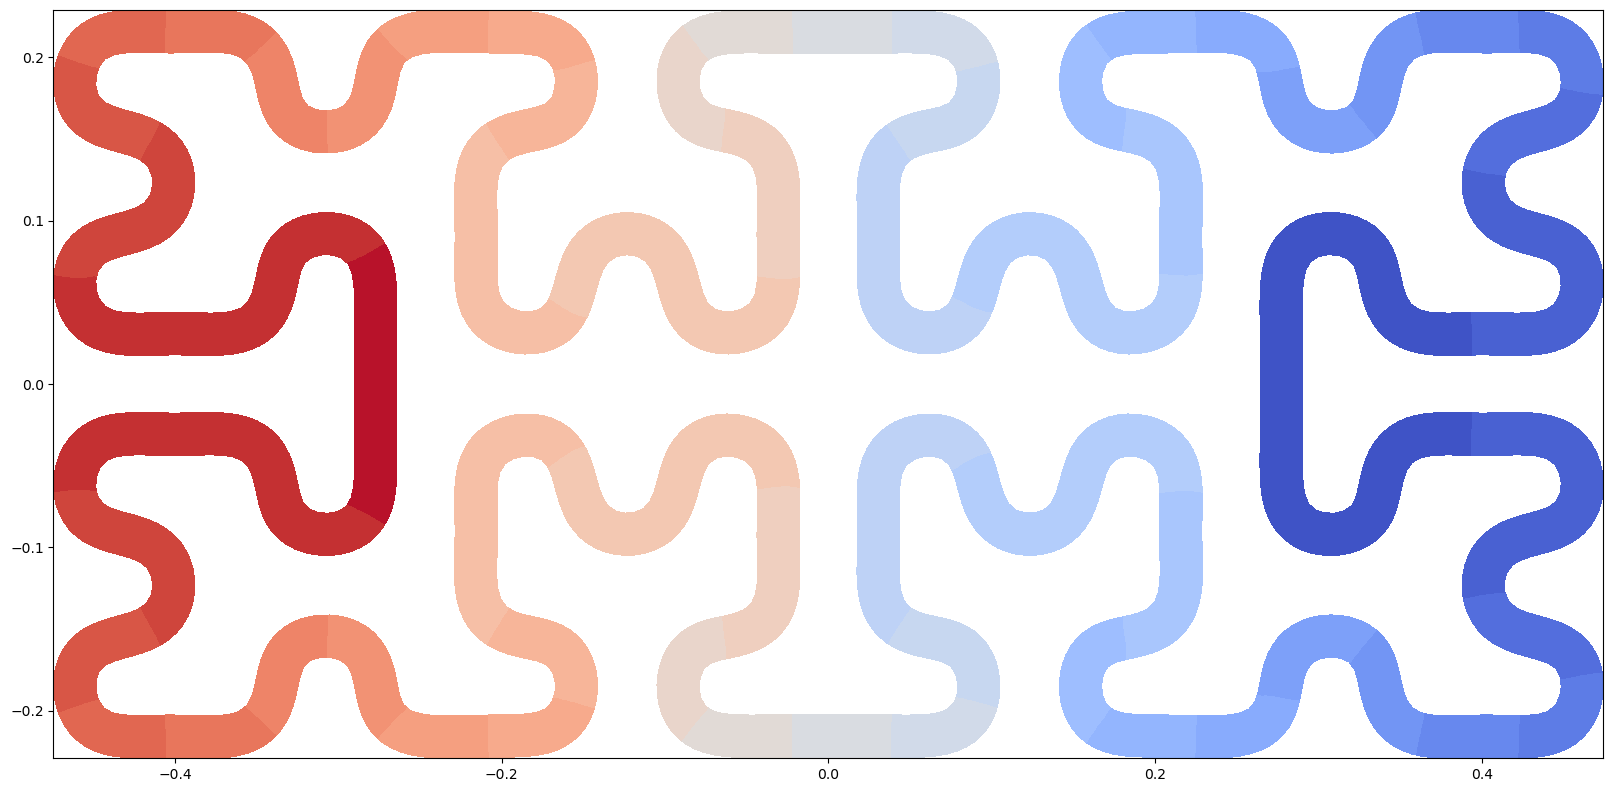

In [27]:
#sol.u.vector()[:] = np.where(np.isnan(sol.u.vector()[:]), 0, sol.u.vector()[:])
#sol.v.vector()[:] = np.where(np.isnan(sol.v.vector()[:]), 0, sol.v.vector()[:])
sol = macro_sol
abs_u = (sol.u * sol.u + sol.v * sol.v) ** 0.5
w = sol.grad_u[1] - sol.grad_v[0]
#print(sol.u.vector()[:])

plt.figure(figsize=(20,20))
dl.plot(abs_u, cmap='coolwarm')#, vmin=0., vmax=1.)
sol.plot_stream(plt.gca(), dom=mesh, bbox=[[-1.,1.], [-1., 1.]], npts=300, color='white', density=5)
plot_boundary_mesh(mesh_bdry_rough, color='k')
remove_axes(plt.gca())
plt.axis("equal")

plt.figure(figsize=(20,20))
dl.plot(abs_u, cmap='coolwarm')#, vmin=0., vmax=1.)
sol.plot_stream(plt.gca(), dom=mesh, bbox=[[-1.,1.], [-1., 1.]], npts=300, color='white', density=5)
plot_boundary_mesh(mesh_bdry_rough, color='k')
remove_axes(plt.gca())
plt.ylim([0.5, 1.0])
plt.xlim([-0.5, 0])

plt.figure(figsize=(20,20))
dl.plot(w, cmap='coolwarm')#, vmin=-10., vmax=10.)

plt.figure(figsize=(20,20))
dl.plot(sol.p, cmap='coolwarm')#, vmin=-20., vmax=20.)